# Session 2 - NNs and Intro to CNN

### Types of Activation function of Output layer:
1- Sigmoid : Binary Classification

2- Softmax: Multi Classes

3- Sigmoid : MultiLabel

4- Linear etc: Regression

----

Input Layer and Output Layer and Hidden layer - structure :

1- Input layer has nodes as number as features -

2- Output Layer mostly is form by dense layer

3- Hidden layers are layers that make different Kinds of ANNs such as CNN, LSTM,RNN, Transformers etc.
( can be dense , Convolution etc)

-------

### TensorFlow vs PyTorch

|                     | **TensorFlow**                         | **PyTorch**                                       |
| ------------------- | -------------------------------------- | ------------------------------------------------- |
| Main library        | `tensorflow` (`tf`)                    | `torch`                                           |
| Main data structure | `Tensor`                               | `Tensor`                                          |
| Example             | `tf.constant([1,2,3])`                 | `torch.tensor([1,2,3])`                           |
| Neural networks     | `tf.keras`                             | `torch.nn`                                        |
| Computation style   | Eager + graph (`tf.function`)          | Primarily eager/dynamic                           |
| GPU support         | Yes                                    | Yes                                               |
| Common use          | Production, TensorFlow/Keras ecosystem | Research, deep learning, flexible experimentation |

**Important:** Both use **tensors** as their fundamental numerical data structure.

So conceptually:

```text
TensorFlow → tf.Tensor
PyTorch    → torch.Tensor
```

And:

```python
# TensorFlow
import tensorflow as tf
x = tf.constant([1, 2, 3])

# PyTorch
import torch
x = torch.tensor([1, 2, 3])
```

The biggest practical difference for a beginner is usually **Keras/TensorFlow's high-level API vs PyTorch's more explicit and flexible `nn.Module` workflow**.








## Iris With NN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numba.parfors.parfor_lowering import hoist

from sklearn.datasets import load_iris
from torchvision.transforms.v2 import Grayscale



In [2]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df
df['Target'] = data.target
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
input_shape = (
    data.data.shape)[1]

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    tf.keras.Input(shape=(4,)),
    tf.keras.layers.Dense(6, activation="relu",name="dense1"),
    tf.keras.layers.Dense(6, activation="relu",name="dense2"),
    tf.keras.layers.Dense(3, activation="softmax",name="softmax"),
],name="Iris_Classifier")

In [5]:
model.summary()

Model: "Iris_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93 (372.00 B)

 Trainable params: 93 (372.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=42)

In [7]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [8]:
tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir="./logs",
    histogram_freq=0,
    write_graph=True,
    write_images=True,
)
history = model.fit(X_train,y_train,epochs=15,batch_size=20,validation_data=(X_test,y_test),callbacks=[tensorboard])

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3333 - loss: 3.3671 - val_accuracy: 0.3333 - val_loss: 3.3219
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3333 - loss: 2.9397 - val_accuracy: 0.3333 - val_loss: 2.8949
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 2.5249 - val_accuracy: 0.3333 - val_loss: 2.4538
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3333 - loss: 2.0850 - val_accuracy: 0.3333 - val_loss: 1.9798
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3333 - loss: 1.6700 - val_accuracy: 0.3333 - val_loss: 1.5890
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 1.3700 - val_accuracy: 0.3333 - val_loss: 1.3052
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5667 - loss: 1.1551 - val_accuracy: 0.6333 - val_loss: 1.1207
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6583 - loss: 1.0216 - val_accuracy: 0.6333 - val_loss: 1.0018


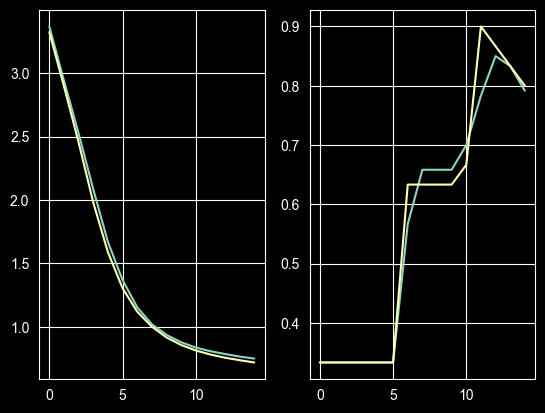

In [13]:
#history.history
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])



plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])



In [15]:
model.evaluate(X_test,y_test)
model.evaluate(X_train,y_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8000 - loss: 0.7199
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7417 - loss: 0.7403 


[0.740341305732727, 0.7416666746139526]

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([2, 0, 2, 2, 1, 0, 2, 2, 1, 2, 2, 0, 0, 0, 0, 2, 2, 1, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0], dtype=int64)

<Axes: >

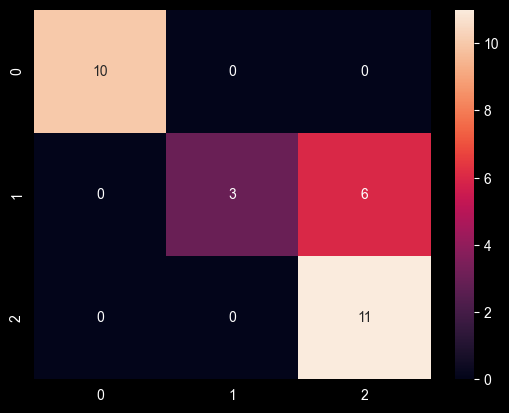

In [24]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="g")


In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.33      0.50         9
           2       0.65      1.00      0.79        11

    accuracy                           0.80        30
   macro avg       0.88      0.78      0.76        30
weighted avg       0.87      0.80      0.77        30



In [38]:
model.get_weights()
#or
model.weights

[<Variable path=Iris_Classifier/dense1/kernel, shape=(4, 6), dtype=float32, value=[[-0.24205025  0.52938336  0.470118   -0.29113725 -0.52898717 -0.05124887]
  [ 0.33999985  0.20464745  0.0511636   0.21436349 -0.32508174  0.22014359]
  [ 0.5045611   0.70233196 -0.71223885  0.6733189   0.4009099   0.14917651]
  [ 0.40912408  0.33809254  0.2603754   0.06039578  0.2419374   0.4014883 ]]>,
 <Variable path=Iris_Classifier/dense1/bias, shape=(6,), dtype=float32, value=[ 0.01818514 -0.02392303  0.14369325 -0.03081153  0.         -0.07811873]>,
 <Variable path=Iris_Classifier/dense2/kernel, shape=(6, 6), dtype=float32, value=[[-0.21143834 -0.44050908  0.3962865  -0.15601076  0.5015598   0.17892216]
  [ 0.32587665  0.62561333  0.12696359  0.07632956  0.12215936  0.45644873]
  [-0.33456612  0.87452817  0.09724317  0.7125522  -0.27727637 -0.9008129 ]
  [-0.27980116  0.2247427  -0.19487196  0.2771195   0.5272336  -0.22587268]
  [-0.3135432   0.1819238   0.2980551   0.34900635  0.12235868 -0.3614754

In [28]:
len(model.weights)

6

`model.weights` represents **all the trainable parameters (weights and biases) of your neural network**.

For your model:

```python
model = Sequential([
    tf.keras.Input(shape=(4,)),
    Dense(6, activation="relu", name="dense1"),
    Dense(6, activation="relu", name="dense2"),
    Dense(3, activation="softmax", name="softmax"),
])
```

`model.weights` contains the parameters of each `Dense` layer.

### For your model

**Dense 1:**

```text
Input: 4
Output: 6
```

So:

```text
kernel/weights → (4, 6)
bias            → (6,)
```

**Dense 2:**

```text
Input: 6
Output: 6
```

So:

```text
kernel/weights → (6, 6)
bias            → (6,)
```

**Output layer:**

```text
Input: 6
Output: 3
```

So:

```text
kernel/weights → (6, 3)
bias            → (3,)
```

Therefore:

```python
model.weights
```

contains **6 tensors**:

```text
dense1 kernel
dense1 bias
dense2 kernel
dense2 bias
softmax kernel
softmax bias
```

You can see their shapes with:

```python
for w in model.weights:
    print(w.name, w.shape)
```

### Important distinction

`model.weights` = the **actual numerical parameters** currently stored in the model.

For example:

```text
dense1 kernel:
[[ 0.12, -0.31, ...],
 [ 0.45,  0.18, ...],
 ...
]
```

During `model.fit()`, backpropagation calculates gradients and the optimizer (Adam in your case) updates these values.

So conceptually:

```text
Input
  ↓
[Weights + Biases]  ← model.weights
  ↓
Prediction
  ↓
Loss
  ↓
Gradients
  ↓
Adam optimizer
  ↓
Updated model.weights
```

And this is why **the weights are what the neural network learns from your training data**.


In [35]:
## See weights during each epoch

class WeightPerEpoch(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        print(epoch+1)

        for layer in self.model.layers:
            if layer.weights:
                print(layer.name)
                print(layer.get_weights())

In [36]:
weight_logger = WeightPerEpoch()

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=20,
    validation_data=(X_test, y_test),
    callbacks=[tensorboard, weight_logger]
)

Epoch 1/15
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9000 - loss: 0.56031
dense1
[array([[-0.24353974,  0.52562124,  0.44134912, -0.28805602, -0.52898717,
        -0.03676103],
       [ 0.35202107,  0.19900872,  0.00765472,  0.208542  , -0.32508174,
         0.23993246],
       [ 0.48821017,  0.7046923 , -0.6830184 ,  0.68246806,  0.4009099 ,
         0.14888042],
       [ 0.38771337,  0.34539148,  0.3065709 ,  0.06882917,  0.2419374 ,
         0.38956344]], dtype=float32), array([ 0.02549656, -0.0327121 ,  0.10557508, -0.02963967,  0.        ,
       -0.05201683], dtype=float32)]
dense2
[array([[-0.2007841 , -0.4274457 ,  0.37730774, -0.13743848,  0.48412275,
         0.16451341],
       [ 0.32537776,  0.6318774 ,  0.11707304,  0.06964374,  0.11579597,
         0.44911718],
       [-0.41727492,  0.8278854 ,  0.1455116 ,  0.5817319 , -0.21520135,
        -0.8545982 ],
       [-0.2687495 ,  0.23515138, -0.21172976,  0.30580118,  0.51229566,
        -0.23743226],
       [-0.313

## CNN part

> In a CNN, the model does **not choose a kernel from a predefined collection of Haar-like features**.
> The **kernel values themselves are learned during training**.

Here is the CNN workflow in the way you are learning it.

## 1. Start with the image

Suppose you have a grayscale image:

```text
28 × 28
```

Each pixel is a number.

For an RGB image, you have channels:

```text
Height × Width × Channels
28 × 28 × 3
```

---

## 2. Convolution layer chooses/starts with filters

Suppose the first convolution has:

```text
kernel size = 3 × 3
number of filters = 32
```

There are actually **32 different 3×3 filters**.

Initially, their values are usually random.

For example, one filter might initially look like:

```text
[ 0.2   -0.1   0.4 ]
[-0.3    0.7  -0.2 ]
[ 0.1    0.5  -0.6 ]
```

Another filter has completely different values.

### The important part

These numbers are **learnable parameters**.

The network eventually learns values that are useful for recognizing patterns.

---

## 3. The filter slides over the image

Exactly as you described.

Take a 3×3 region:

```text
Image              Kernel

[ 2  1  0 ]        [ a b c ]
[ 1  3  2 ]   ×    [ d e f ]
[ 0  1  2 ]        [ g h i ]
```

Element-wise multiplication + summation:

$$
2a + 1b + 0c + 1d + 3e + 2f + 0g + 1h + 2i
$$

This produces **one number**.

Then the filter moves to the next position.

Eventually you get:

```text
Feature Map
┌───────────────┐
│ 0.2  1.4  ... │
│ 0.7  2.1  ... │
│ ...           │
└───────────────┘
```

That is your **feature map**.

---

## 4. Why does 28×28 become 26×26?

If:

```text
Input = 28 × 28
Kernel = 3 × 3
Stride = 1
Padding = 0
```

then:

$$
Output = \frac{28-3}{1}+1 = 26
$$

So:

```text
28 × 28
   ↓
3×3 convolution
   ↓
26 × 26
```

Yes, your understanding here is correct.

With `padding="same"`:

```text
28 × 28
   ↓
3×3 convolution + padding
   ↓
28 × 28
```

---

# 5. But you have MANY filters

This is very important.

Suppose:

```python
Conv2D(32, kernel_size=(3,3))
```

You don't get one feature map.

You get:

```text
Filter 1 → Feature Map 1
Filter 2 → Feature Map 2
Filter 3 → Feature Map 3
...
Filter 32 → Feature Map 32
```

So the output might be:

```text
26 × 26 × 32
```

Each filter can learn to respond to different patterns.

---

# 6. What does each filter learn?

This is the beautiful part of CNNs.

In early layers, filters often learn relatively simple patterns such as:

```text
edges
│
─
/
\
corners
simple textures
```

Later layers combine those simple features.

For example:

```text
Layer 1
   ↓
edges

Layer 2
   ↓
corners / curves / textures

Layer 3
   ↓
parts of objects

Layer 4
   ↓
higher-level structures

Final layers
   ↓
object/class
```

So the CNN **automatically learns the feature hierarchy**.

---

# 7. Where does ReLU come in?

After convolution:

$$
Z = X * K + b
$$

you normally apply an activation function:

$$
A = ReLU(Z)
$$

where:

$$
ReLU(x)=\max(0,x)
$$

So:

```text
Convolution
     ↓
Feature map
     ↓
ReLU
     ↓
Activated feature map
```

ReLU essentially removes negative activations:

```text
[-2,  3, -1,  5]
       ↓ ReLU
[ 0,  3,  0,  5]
```

It also introduces **non-linearity**, which is crucial for learning complex patterns.

---

# 8. What does pooling do?

For example, MaxPooling:

```text
[1  3]
[2  5]
```

takes the maximum:

```text
5
```

So:

```text
Feature map
     ↓
MaxPooling
     ↓
smaller feature map
```

For example:

```text
28 × 28
    ↓
14 × 14
```

Pooling reduces spatial size and therefore reduces computation.

It also makes the representation somewhat less sensitive to small shifts in the object.

---

# 9. Your comparison with classical ML is VERY important

You are thinking about this correctly.

### Classical computer vision

You might manually design features:

```text
Image
  ↓
Haar features
  ↓
HOG
  ↓
SIFT
  ↓
etc.
  ↓
ML classifier
```

**You decide what features to extract.**

For example, Haar features are manually designed patterns that measure differences between regions.

---

### CNN

You don't manually tell the network:

> "Look for this edge."

Instead:

```text
Image
  ↓
Random/initialized filters
  ↓
Convolution
  ↓
Feature maps
  ↓
Loss
  ↓
Backpropagation
  ↓
Update filter weights
  ↓
Better filters
  ↓
Repeat
```

Eventually the network discovers filters that are useful for the task.

---

# The most important correction to your idea

You said:

> "it determines which kernel (Haar-like feature) are important and use them?"

**Almost, but not exactly.**

It's better to think:

> **The CNN learns the numerical values of its kernels so that the resulting feature maps become useful for minimizing the classification loss.**

It's not selecting from a predefined list of Haar features.

For example, instead of us giving it:

```text
Edge filter
[ -1  0  1 ]
[ -1  0  1 ]
[ -1  0  1 ]
```

we give it a trainable kernel:

```text
[ ?  ?  ? ]
[ ?  ?  ? ]
[ ?  ?  ? ]
```

and training gradually learns:

```text
[ -0.8  0.1  0.9 ]
[ -0.7  0.0  0.8 ]
[ -0.9  0.2  1.0 ]
```

if something like that is useful for the task.

---

## The complete CNN mental model

Keep this pipeline in your head:

```text
                    CNN
                     │
                     ▼
                  IMAGE
                     │
                     ▼
              CONVOLUTION
                     │
          ┌──────────┴──────────┐
          ▼          ▼          ▼
       Filter 1   Filter 2   Filter 3 ...
          │          │          │
          ▼          ▼          ▼
      Feature 1  Feature 2  Feature 3
          │          │          │
          └──────────┬──────────┘
                     ▼
                    ReLU
                     │
                     ▼
                  Pooling
                     │
                     ▼
              More Conv Layers
                     │
                     ▼
           Higher-level features
                     │
                     ▼
                  Flatten
                     │
                     ▼
               Dense layers
                     │
                     ▼
                Prediction
```

And during training:

```text
Prediction
    ↓
   Loss
    ↓
Backpropagation
    ↓
Gradients
    ↓
Update CNN kernels
    ↓
Better feature detectors
```

**This last part is the key difference from traditional hand-engineered features:** the CNN learns the feature detectors **end-to-end from the data and the task loss**.


**Pooling is a downsampling operation** in a CNN. It takes a small region of a feature map and summarizes it into **one value**, making the feature map smaller.

The most common type is **Max Pooling**.

### Example: 2×2 Max Pooling

Suppose your convolution produced:

```text
[ 1   3   2   4 ]
[ 5   6   1   2 ]
[ 7   2   8   3 ]
[ 4   1   5   9 ]
```

Use:

```text
pool_size = 2×2
stride = 2
```

Take each 2×2 region:

```text
[1  3]       [2  4]
[5  6]       [1  2]

  ↓             ↓

   6             4
```

Then:

```text
[7  2]       [8  3]
[4  1]       [5  9]

  ↓             ↓

   7             9
```

So the result is:

```text
[ 6  4 ]
[ 7  9 ]
```

You went from:

```text
4 × 4
  ↓
2 × 2
```

### Why do this?

The main purposes are:

1. **Reduce spatial dimensions**

   ```text
   28×28 → 14×14
   ```

2. **Reduce computation and memory**

3. **Keep strong/important activations**

   With max pooling, if a feature detector strongly detects something in a 2×2 region:

   ```text
   [0.1  0.2]
   [0.9  0.3]
   ```

   Max pooling keeps:

   ```text
   0.9
   ```

4. **Give some tolerance to small translations**

   If an edge moves slightly within that 2×2 region, the maximum can remain similar.

---

### Max pooling vs convolution

This distinction is important:

**Convolution:**

```text
image
 ↓
learned kernel
 ↓
feature map
```

The kernel's numbers are **learned**.

**Pooling:**

```text
feature map
 ↓
fixed operation
 ↓
smaller feature map
```

The pooling operation **does not learn weights**.

For max pooling:

$$
y = \max(x_1,x_2,x_3,x_4)
$$

There is no trainable kernel.

So a typical CNN might be:

```text
Image
 ↓
Conv       ← learns filters
 ↓
ReLU
 ↓
MaxPool    ← no learning, just downsamples
 ↓
Conv       ← learns new filters
 ↓
ReLU
 ↓
MaxPool
 ↓
...
```

**One sentence to remember:**

> **Pooling takes a local region of a feature map and compresses it into a smaller representation, usually by keeping the maximum or average value.**


Yes. The most useful way to understand **convolution in CNNs** is to separate the **signal-processing meaning** from the **CNN meaning**.

## 1. Convolution in signal processing

Suppose you have a 1D signal:

$$
x = [x_0,x_1,x_2,\dots]
$$

and a small filter/kernel:

$$
h = [h_0,h_1,h_2]
$$

Convolution asks:

> **How strongly does this filter pattern match the signal at each position?**

Mathematically, the discrete convolution is:

$$
y[n] = \sum_k x[k]h[n-k]
$$

The important idea is:

**slide → multiply → sum**

---

## 2. Simple example

Signal:

$$
x=[1,2,3,4,5]
$$

Kernel:

$$
h=[1,0,-1]
$$

Take the first 3 values:

$$
[1,2,3]
$$

Multiply element-by-element:

$$
1(1)+2(0)+3(-1)
$$

$$
=1+0-3=-2
$$

Move the kernel one position:

$$
[2,3,4]
$$

$$
2(1)+3(0)+4(-1)=-2
$$

Again:

$$
[3,4,5]
$$

$$
3(1)+4(0)+5(-1)=-2
$$

So the output is:

$$
[-2,-2,-2]
$$

The kernel has essentially detected the **change/slope** in the signal.

---

# 3. What does the multiplication actually mean?

This is the key concept.

Suppose:

$$
x=[1,2,3]
$$

and:

$$
h=[1,0,-1]
$$

The dot product is:

$$
[1,2,3]\cdot[1,0,-1]
$$

$$
=1(1)+2(0)+3(-1)
$$

$$
=-2
$$

The result tells us how much the local signal resembles the pattern represented by the kernel.

If the local signal has a pattern similar to the kernel, the result can have a large magnitude.

If it doesn't match, the result tends to be smaller.

So you can think of a kernel as a **pattern detector**.

---

# 4. Now move to images

An image is basically a **2D signal**.

For example:

$$
X =
\begin{bmatrix}
1&2&3&4\\
5&6&7&8\\
9&10&11&12\\
13&14&15&16
\end{bmatrix}
$$

Suppose the kernel is:

$$
K =
\begin{bmatrix}
1&0\\
0&-1
\end{bmatrix}
$$

Take the top-left 2×2 region:

$$
\begin{bmatrix}
1&2\\
5&6
\end{bmatrix}
$$

Element-wise multiplication:

$$
\begin{bmatrix}
1&2\\
5&6
\end{bmatrix}
\odot
\begin{bmatrix}
1&0\\
0&-1
\end{bmatrix}
$$

gives:

$$
\begin{bmatrix}
1&0\\
0&-6
\end{bmatrix}
$$

Then sum:

$$
1+0+0-6=-5
$$

That **one number** becomes one pixel in the output feature map.

Then the kernel moves:

```text
Image
┌───────────────┐
│██              │
│██   →          │
│               │
│               │
└───────────────┘
```

Calculate another dot product → another output number.

Continue across the image → **feature map**.

---

# 5. Why does this detect edges?

Consider a vertical edge.

Imagine the left side of an image is dark:

$$
0,0,0
$$

and the right side is bright:

$$
1,1,1
$$

A kernel such as:

$$
K=
\begin{bmatrix}
-1&0&1\\
-1&0&1\\
-1&0&1
\end{bmatrix}
$$

is sensitive to:

```text
dark → bright
```

For a region:

$$
X=
\begin{bmatrix}
0&0&1\\
0&0&1\\
0&0&1
\end{bmatrix}
$$

the convolution gives:

$$
(-1)(0)+(0)(0)+(1)(1)
$$

for each row.

So:

$$
0+1+0+1+0+1=3
$$

A strong positive response.

But if the region is completely uniform:

$$
X=
\begin{bmatrix}
0&0&0\\
0&0&0\\
0&0&0
\end{bmatrix}
$$

the response is:

$$
0
$$

So the filter responds strongly to a particular **local pattern**.

---

# 6. This is where CNN becomes interesting

In traditional signal processing, **you choose the filter**.

For example, you might manually choose:

$$
K=
\begin{bmatrix}
-1&0&1\\
-1&0&1\\
-1&0&1
\end{bmatrix}
$$

because you know it detects vertical edges.

### CNN does something different.

You give the CNN:

```text
Image
+
random/initialized kernels
+
correct labels
```

Then training does:

$$
\text{Image}
\rightarrow
\text{Convolution}
\rightarrow
\text{Prediction}
\rightarrow
\text{Loss}
$$

Then backpropagation calculates:

$$
\frac{\partial L}{\partial K}
$$

This tells the network:

> "How should I change the kernel values to reduce the loss?"

Then the optimizer updates:

$$
K_{\text{new}}
=
K_{\text{old}}
-
\eta
\frac{\partial L}{\partial K}
$$

where \(\eta\) is the learning rate.

So the CNN **learns the filters**.

---

# 7. One subtle but important point: CNN "convolution"

Strictly speaking, what most CNN libraries implement is actually **cross-correlation**, not mathematical convolution.

Mathematical convolution flips the kernel:

$$
K(i,j)\rightarrow K(-i,-j)
$$

But deep-learning libraries generally perform:

$$
Y(i,j)
=
\sum_{m}\sum_{n}
X(i+m,j+n)K(m,n)
$$

without flipping the kernel.

People still call this operation **convolution** because the terminology is standard in deep learning.

For learning CNNs, you usually don't need to worry about the distinction initially.

---

# The core idea

Think of convolution as:

$$
\boxed{\text{local region} \cdot \text{kernel} \rightarrow \text{one number}}
$$

Then repeat everywhere:

$$
\boxed{
\text{image}
\rightarrow
\text{many local dot products}
\rightarrow
\text{feature map}
}
$$

And during CNN training:

$$
\boxed{
\text{loss}
\rightarrow
\text{gradient}
\rightarrow
\text{update kernel}
\rightarrow
\text{better feature detector}
}
$$

So when you hear **"a convolutional filter detects an edge"**, mathematically what is happening is simply a **sliding dot product between a local image patch and the filter's weights**.


Exactly — **you've got the core idea**, with one small correction.

### During convolution

For every small patch of the image, the kernel computes a **dot product**:

$$
\text{score} = \text{image patch} \cdot \text{kernel}
$$

That score tells us how strongly that patch **responds to the pattern represented by the kernel**.

So:

```text
Image
 ↓
[small patch] ── compare with kernel ──→ score
[small patch] ── compare with kernel ──→ score
[small patch] ── compare with kernel ──→ score
...
 ↓
Feature map
```

A high absolute response means the local image pattern aligns strongly with the kernel's pattern.

### Then gradient descent

Here's the correction:

> The gradient does **not directly make the kernel "similar to the image."**

Instead, it asks:

> **"How should I change the kernel so that the final prediction becomes more correct?"**

The chain is:

```text
Kernel
  ↓
Convolution
  ↓
Feature map
  ↓
ReLU / pooling / more layers
  ↓
Prediction
  ↓
Loss
  ↓
Gradient
  ↓
Update kernel
```

So suppose the network needs to recognize **cats**.

Initially, a kernel might detect some random pattern.

After many training examples, backpropagation may discover that changing that kernel makes the **final classification loss smaller**. Eventually it might become an effective detector for something like an edge, curve, texture, etc.

So your mental model should be:

> **Convolution asks: "Where in the image does this kernel's pattern appear?"**
> **Training asks: "How should I change the kernel so that these detected patterns help me make the correct prediction?"**

And this is the key difference from manually designed Haar features: **you don't tell the CNN what pattern to detect; the training process learns useful patterns through the loss function.**


In [42]:
X = np.arange(1,13).reshape(3,4)

In [43]:
X

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [47]:
X_n=np.pad(X,pad_width=(1,1),mode='constant',constant_values=0)


In [49]:
kernel = np.ones((3,3))
np.convolve(X_n,kernel)

# Just 1D works

ValueError: object too deep for desired array

In [52]:
from scipy.signal import convolve2d

kernel = np.ones((3,3))

result = convolve2d(X_n, kernel, mode="valid")

print(result)

[[14. 24. 30. 22.]
 [33. 54. 63. 45.]
 [30. 48. 54. 38.]]


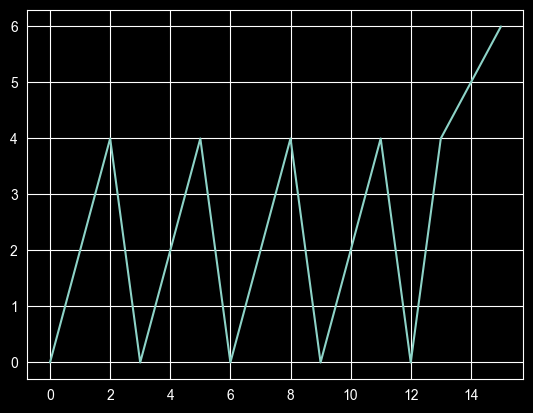

In [60]:
X = np.array([0,2,4,0,2,4,0,2,4,0,2,4,0,4,5,6])
plt.plot(X)


In [92]:
kerenl = np.array([1,1,2])

np.convolve(X,kerenl,mode="valid")

array([ 7, 11, 15])

In [93]:
X = np.array([1,2,3,4,5])
kernel = np.array([1,2,3])

np.convolve(X,kernel,mode="full")

array([ 1,  4, 10, 16, 22, 22, 15])

In [94]:
np.convolve(X,kernel,mode="same")


array([ 4, 10, 16, 22, 22])

In [95]:
np.convolve(X,kernel,mode="valid")


array([10, 16, 22])

Absolutely. Let's do **only `full`**, step by step, by hand.

We have:

```python
X      = [1, 2, 3, 4, 5]
kernel = [1, 2, 3]
```

For `np.convolve`, the kernel is **flipped**:

```text
kernel:        [1, 2, 3]
flip it:       [3, 2, 1]
```

Now slide `[3,2,1]` across `X`.

### Step 1 — first position

Only `1` overlaps:

```text
X:       1  2  3  4  5
kernel:  3
```

So:

```text
1 × 3 = 3
```

First output = **3**

---

### Step 2

Now:

```text
X:       1  2  3  4  5
kernel:  3  2
```

Calculate:

```text
1×3 + 2×2
= 3 + 4
= 7
```

Second output = **7**

---

### Step 3

Now the kernel completely overlaps:

```text
X:       1  2  3  4  5
kernel:     3  2  1
```

Calculate:

```text
1×3 + 2×2 + 3×1
= 3 + 4 + 3
= 10
```

Third output = **10**

---

### Step 4

Move one position right:

```text
X:       1  2  3  4  5
kernel:        3  2  1
```

Calculate:

```text
2×3 + 3×2 + 4×1
= 6 + 6 + 4
= 16
```

Fourth = **16**

---

### Step 5

Move again:

```text
X:       1  2  3  4  5
kernel:           3  2  1
```

```text
3×3 + 4×2 + 5×1
= 9 + 8 + 5
= 22
```

Fifth = **22**

---

### Step 6

Now the kernel is partly outside on the right:

```text
X:       1  2  3  4  5
kernel:              3  2  1
                         ↑
                       outside
```

Only `4` and `5` overlap:

```text
4×3 + 5×2
= 12 + 10
= 22
```

Sixth = **22**

---

### Step 7

Only `5` overlaps:

```text
5×3 = 15
```

Seventh = **15**

So:

```python
np.convolve(X, kernel, mode="full")
```

gives:

```text
[3, 7, 10, 16, 22, 22, 15]
```

### The whole idea

```text
[1,2,3,4,5]
   ↓
slide [3,2,1]
   ↓
multiply corresponding numbers
   ↓
add them
   ↓
[3,7,10,16,22,22,15]
```

And **this is why `full` has 7 values**:

```text
5 + 3 - 1 = 7
```

If you understand this, then **`valid` is much easier**: we simply throw away the positions where the kernel is hanging outside the signal.



Absolutely. Let's do **only `full`**, step by step, by hand.

We have:

```python
X      = [1, 2, 3, 4, 5]
kernel = [1, 2, 3]
```

For `np.convolve`, the kernel is **flipped**:

```text
kernel:        [1, 2, 3]
flip it:       [3, 2, 1]
```

Now slide `[3,2,1]` across `X`.

### Step 1 — first position

Only `1` overlaps:

```text
X:       1  2  3  4  5
kernel:  3
```

So:

```text
1 × 3 = 3
```

First output = **3**

---

### Step 2

Now:

```text
X:       1  2  3  4  5
kernel:  3  2
```

Calculate:

```text
1×3 + 2×2
= 3 + 4
= 7
```

Second output = **7**

---

### Step 3

Now the kernel completely overlaps:

```text
X:       1  2  3  4  5
kernel:     3  2  1
```

Calculate:

```text
1×3 + 2×2 + 3×1
= 3 + 4 + 3
= 10
```

Third output = **10**

---

### Step 4

Move one position right:

```text
X:       1  2  3  4  5
kernel:        3  2  1
```

Calculate:

```text
2×3 + 3×2 + 4×1
= 6 + 6 + 4
= 16
```

Fourth = **16**

---

### Step 5

Move again:

```text
X:       1  2  3  4  5
kernel:           3  2  1
```

```text
3×3 + 4×2 + 5×1
= 9 + 8 + 5
= 22
```

Fifth = **22**

---

### Step 6

Now the kernel is partly outside on the right:

```text
X:       1  2  3  4  5
kernel:              3  2  1
                         ↑
                       outside
```

Only `4` and `5` overlap:

```text
4×3 + 5×2
= 12 + 10
= 22
```

Sixth = **22**

---

### Step 7

Only `5` overlaps:

```text
5×3 = 15
```

Seventh = **15**

So:

```python
np.convolve(X, kernel, mode="full")
```

gives:

```text
[3, 7, 10, 16, 22, 22, 15]
```

### The whole idea

```text
[1,2,3,4,5]
   ↓
slide [3,2,1]
   ↓
multiply corresponding numbers
   ↓
add them
   ↓
[3,7,10,16,22,22,15]
```

And **this is why `full` has 7 values**:

```text
5 + 3 - 1 = 7
```

If you understand this, then **`valid` is much easier**: we simply throw away the positions where the kernel is hanging outside the signal.


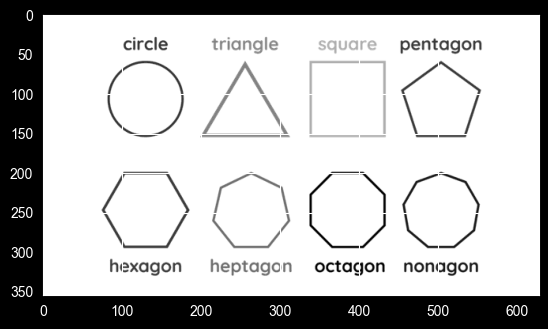

In [78]:
import cv2

img = cv2.imread('images.png',cv2.IMREAD_GRAYSCALE)
plt.imshow(img,cmap='gray')


In [90]:
kernel = np.array([[-1,1],
                   [1,-1]])

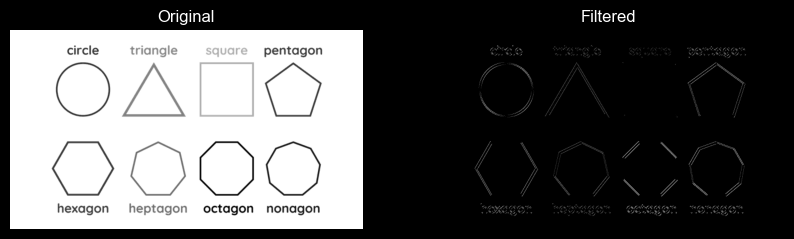

In [91]:
img_f = cv2.filter2D(img, -1, kernel)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_f, cmap='gray')
plt.title("Filtered")
plt.axis("off")

plt.show()